In [1]:
import os
import cv2
import pydicom
import pandas as pd
import numpy as np 
import tensorflow as tf 
import random
from tqdm.notebook import tqdm 
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
from tensorflow_addons.optimizers import RectifiedAdam
import keras
from tensorflow.keras import Model
import tensorflow.keras.backend as K
import tensorflow.keras.layers as L
import tensorflow.keras.models as M
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import (
    Dense, Dropout, Activation, Flatten, Input, BatchNormalization, GlobalAveragePooling2D, Add, Conv2D, AveragePooling2D, 
    LeakyReLU, Concatenate 
)
import efficientnet.tfkeras as efn
import h5py
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt
import warnings


import seaborn as sns
from PIL import Image
import json

# Function to set seed for reproducibility(random number generator)
def seed_everything(seed=2020):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
seed_everything(42)

# Configuration for TensorFlow session
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

#supress tensorflow addons warning
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow_addons")

train = pd.read_csv('osic-pulmonary-fibrosis-progression/train.csv') 


/Users/daehwanyoo/project/UM_MED_PF/myenv/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:
# Function to extract features from the DataFrame
# Normalize
def get_tab(df):
    # age (calculated closer to 0-1)
    vector = [(df.Age.values[0] - 30) / 30] 
    
    # male:0, female: 1
    if df.Sex.values[0] == 'male':
       vector.append(0)
    else:
       vector.append(1)
    
    # never smoked: 0, 0/ex-smoker: 1,1/currently: 0,1
    if df.SmokingStatus.values[0] == 'Never smoked':
        vector.extend([0,0])
    elif df.SmokingStatus.values[0] == 'Ex-smoker':
        vector.extend([1,1])
    elif df.SmokingStatus.values[0] == 'Currently smokes':
        vector.extend([0,1])
    else:
        vector.extend([1,0])

    return np.array(vector) 

A_slope = {} # computed value (slope'a') for each patient
TAB = {} # tabular data for each patient
P = [] # unique patient identifiers
# save patient-specific datasets/linear regression

for i, p in tqdm(enumerate(train.Patient.unique())):
    sub = train.loc[train.Patient == p, :] 
    fvc = sub.FVC.values
    weeks = sub.Weeks.values
    c = np.vstack([weeks, np.ones(len(weeks))]).T
    a, b = np.linalg.lstsq(c, fvc, rcond=None)[0] #fvc=a*weeks+b
    # a = how much FVC changes per week
    # b = constant (0), not used for this
    
    A_slope[p] = a
    TAB[p] = get_tab(sub)
    P.append(p)

print("A_slope:", A_slope)
print("TAB:", TAB)
print("Amount of Patient identifier:", len(P))



0it [00:00, ?it/s]

A_slope: {'ID00007637202177411956430': -3.1671258700696026, 'ID00009637202177434476278': -9.379955123410637, 'ID00010637202177584971671': -17.04280323873905, 'ID00011637202177653955184': -4.5489251297257445, 'ID00012637202177665765362': -8.54307852898669, 'ID00014637202177757139317': -14.033411631297666, 'ID00015637202177877247924': -7.578959348113091, 'ID00019637202178323708467': -5.7299607299607045, 'ID00020637202178344345685': -7.370692539310823, 'ID00023637202179104603099': -2.549151772190275, 'ID00025637202179541264076': -10.81815281544106, 'ID00026637202179561894768': -2.9678593086719505, 'ID00027637202179689871102': -5.4943685597891205, 'ID00030637202181211009029': -4.687772738940666, 'ID00032637202181710233084': -14.362868550368603, 'ID00035637202182204917484': -9.673158832184635, 'ID00038637202182690843176': -0.8007971241012665, 'ID00042637202184406822975': 0.5981338481338551, 'ID00047637202184938901501': -10.831542461005142, 'ID00048637202185016727717': -1.1904083570750204, '

In [3]:
# read DICOM, normalized
def get_img(path):
    d = pydicom.dcmread(path)
    return cv2.resize(d.pixel_array / 2**11, (512, 512))

# Class for creating a custom batch generator
class IGenerator(Sequence):
    BAD_ID = ['ID00011637202177653955184', 'ID00052637202186188008618']
    def __init__(self, keys, a, tab, batch_size=128):
        self.keys = [k for k in keys if k not in self.BAD_ID]
        self.a = a
        self.tab = tab
        self.batch_size = batch_size
        
        self.train_data = {}
        for p in train.Patient.values:
            self.train_data[p] = os.listdir(f'osic-pulmonary-fibrosis-progression/train/{p}/')

    
    def __len__(self):
        return 1000
    
    def __getitem__(self, idx):
        x = [] # DICOM file appends
        a, tab = [], [] 
        keys = np.random.choice(self.keys, size = self.batch_size)
        for k in keys:
            try:
                i = np.random.choice(self.train_data[k], size=1)[0]
                img = get_img(f'osic-pulmonary-fibrosis-progression/train/{k}/{i}')
                x.append(img)
                a.append(self.a[k])
                tab.append(self.tab[k])
            except:
                print(k, i)
       
        x,a,tab = np.array(x), np.array(a), np.array(tab)
        x = np.expand_dims(x, axis=-1)
        
        print(f"Batch {idx}: Number of images = {len(x)}, Number of 'a' values = {len(a)}, Number of tabular data entries = {len(tab)}")

        
        return [x, tab] , a


x: input image data
x2: tabular data

In [4]:

# Function to get EfficientNet model
def get_efficientnet(model, shape):
    models_dict = {
        'b0': efn.EfficientNetB0(input_shape=shape,weights=None,include_top=False),
        'b1': efn.EfficientNetB1(input_shape=shape,weights=None,include_top=False),
        'b2': efn.EfficientNetB2(input_shape=shape,weights=None,include_top=False),
        'b3': efn.EfficientNetB3(input_shape=shape,weights=None,include_top=False),
        'b4': efn.EfficientNetB4(input_shape=shape,weights=None,include_top=False),
        'b5': efn.EfficientNetB5(input_shape=shape,weights=None,include_top=False),
        'b6': efn.EfficientNetB6(input_shape=shape,weights=None,include_top=False),
        'b7': efn.EfficientNetB7(input_shape=shape,weights=None,include_top=False)
    }
    return models_dict[model]



# Function to build the model
def build_model(shape=(512, 512, 1), model_class=None):
    inp = Input(shape=shape) #image data
    base = get_efficientnet(model_class, shape)
    x = base(inp)
    x = GlobalAveragePooling2D()(x) #reduce dimensionality

    x_shape = x.shape  # Get the shape of x
    print("Shape of 'x' tensor:", x_shape)  # Print the shape instead of length
    
    x = Dropout(0.5)(x)  #prevent overfitting, usually 0.3-0.5
    print("Shape of 'x' tensor after dropout:", x.shape)  # Print the shape instead of length

    # x_shape, x2_shape: number of elements in the vector

    inp2 = Input(shape=(4,)) #tabulr data
    x2 = tf.keras.layers.GaussianNoise(0.2)(inp2)
    x2_shape = x2.shape  # Get the shape of x2
    print("Shape of 'x2' tensor:", x2_shape)  # Print the shape instead of length

    x = Concatenate()([x, x2]) 
    x_shape = x.shape  # Get the shape of x
    print("Shape of 'x' tensor:", x_shape)  # Print the shape instead of length

    
    # What's the default to dropout

    x = Dense(1)(x)
    x_shape = x.shape  # Get the shape of x
    
    print("Shape of 'x' tensor:", x_shape)  # Print the shape instead of length

    print("Final value of 'x':", x)

    model = Model([inp, inp2] , x)

    return model



In [5]:
# Model classes to build
model_classes = ['b5'] #['b0','b1','b2','b3',b4','b5','b6','b7']

# Initialize your models here
models = [build_model(shape=(512, 512, 1), model_class=m) for m in model_classes]
print(f"\nInitialized {len(models)} models: {model_classes}.")


Shape of 'x' tensor: (None, 2048)
Shape of 'x' tensor after dropout: (None, 2048)
Shape of 'x2' tensor: (None, 4)
Shape of 'x' tensor: (None, 2052)
Shape of 'x' tensor: (None, 1)
Final value of 'x': KerasTensor(type_spec=TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), name='dense/BiasAdd:0', description="created by layer 'dense'")

Initialized 1 models: ['b5'].


Create weights: randomly initialized and saved
P splited into tr_p (training) and vl_p(validation)
P: collection of unique identifiers for patients in the dataset


Weights generated successfully.
Number of models: 1
Number of patient identifiers in training set (tr_p): 140
Number of patient identifiers in validation set (vl_p): 36


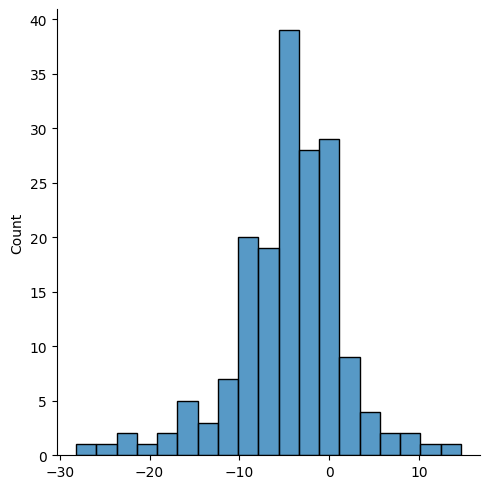

In [6]:
# Directory to save the weights
weights_directory = 'osic_model_weights'

# Ensure the directory exists
os.makedirs(weights_directory, exist_ok=True)

# Function to generate random weights
def generate_weights(model, model_class):
    # Generate random weights
    weights = [np.random.randn(*w.shape) for w in model.get_weights()]
    
    # Save weights to HDF5 file
    with h5py.File(os.path.join(weights_directory, f'{model_class}.h5'), 'w') as f:
        for i, w in enumerate(weights):
            f.create_dataset(f'weight_{i}', data=w)

# Generate weights for each model
for model, model_class in zip(models, model_classes):
    generate_weights(model, model_class)

print("\nWeights generated successfully.")
print('Number of models: ' + str(len(models)))

tr_p, vl_p = train_test_split(P, 
                              shuffle=True, 
                              train_size= 0.8) 
print("Number of patient identifiers in training set (tr_p):", len(tr_p))
print("Number of patient identifiers in validation set (vl_p):", len(vl_p))

sns.displot(list(A_slope.values()))
plt.show()

# Caculate the score
def score(fvc_true, fvc_pred, sigma):
    sigma_clip = np.maximum(sigma, 70) # changed from 70, trie 66.7 too
    delta = np.abs(fvc_true - fvc_pred)
    delta = np.minimum(delta, 1000)
    sq2 = np.sqrt(2)
    metric = (delta / sigma_clip)*sq2 + np.log(sigma_clip* sq2)
    return np.mean(metric)



Using trained model for predictions(_a=model.predict([x, tab])) -> predicte value

For graph: x-axis: different set of input data for which the model has made a prediction.
Y-axis: actual output; predicted slope of FVC decline

Red dot: quantile value calculated from _a. Since q is set to 0.8, it placed at the value higher than 80% of all other prediction.(1. sort all the predicted value, find the value at the position that 80% along the sorted list)


Number of unique patient identifiers in the test set: 5
Processing Patient ID: ID00419637202311204720264
1/1 [==============================] - 5s 5s/step
18


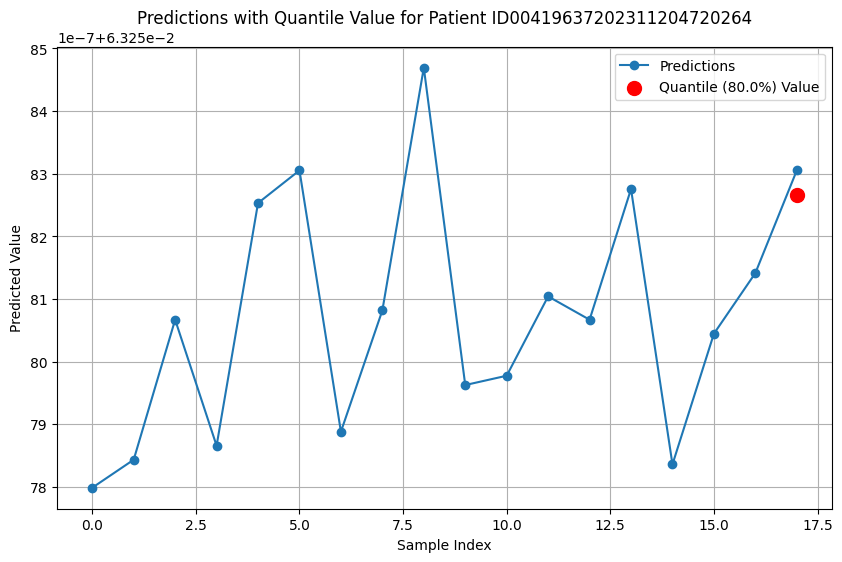

Processing Patient ID: ID00421637202311550012437
2/2 [==============================] - 9s 1s/step
40


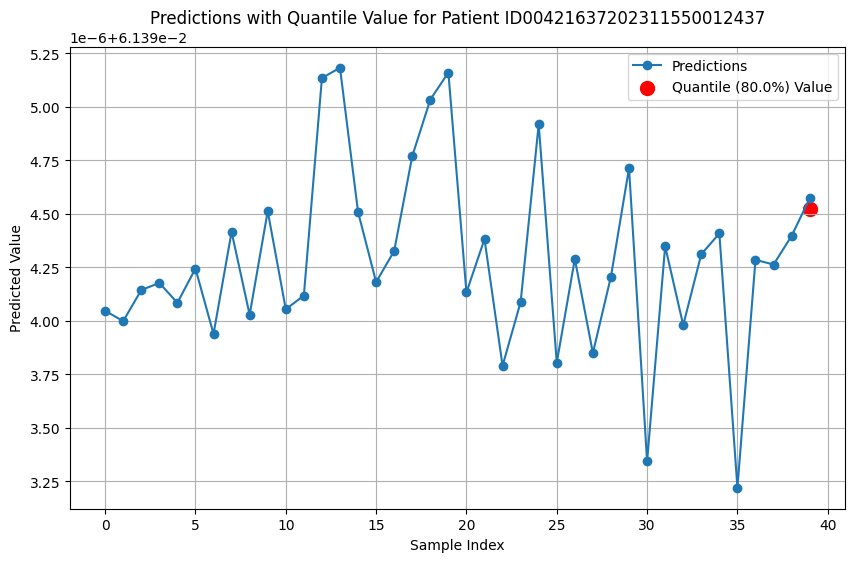

Processing Patient ID: ID00422637202311677017371
10/10 [==============================] - 55s 5s/step
308


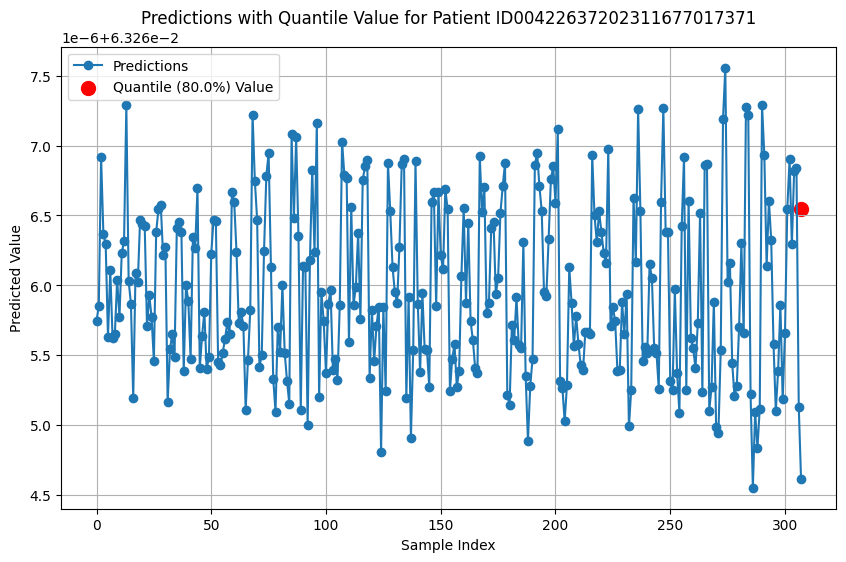

Processing Patient ID: ID00423637202312137826377
6/6 [==============================] - 33s 5s/step
188


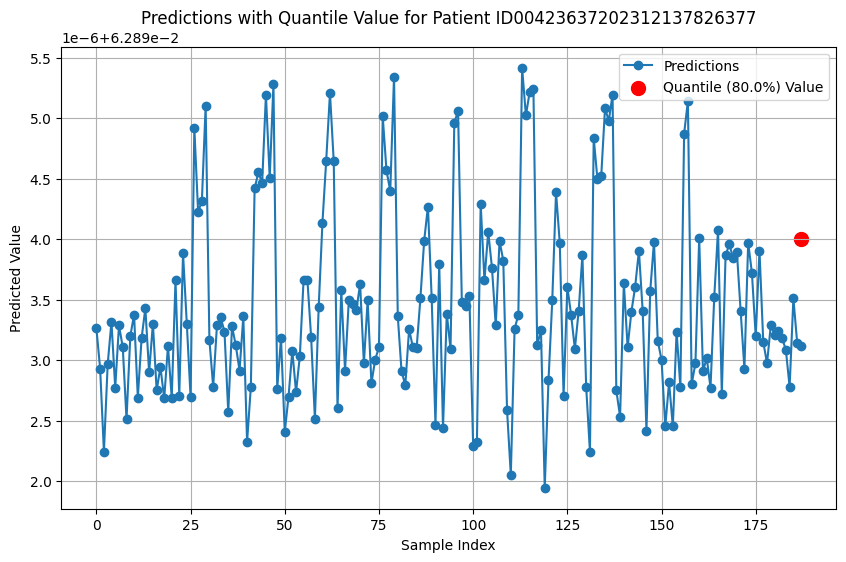

Processing Patient ID: ID00426637202313170790466
9/9 [==============================] - 49s 5s/step
265


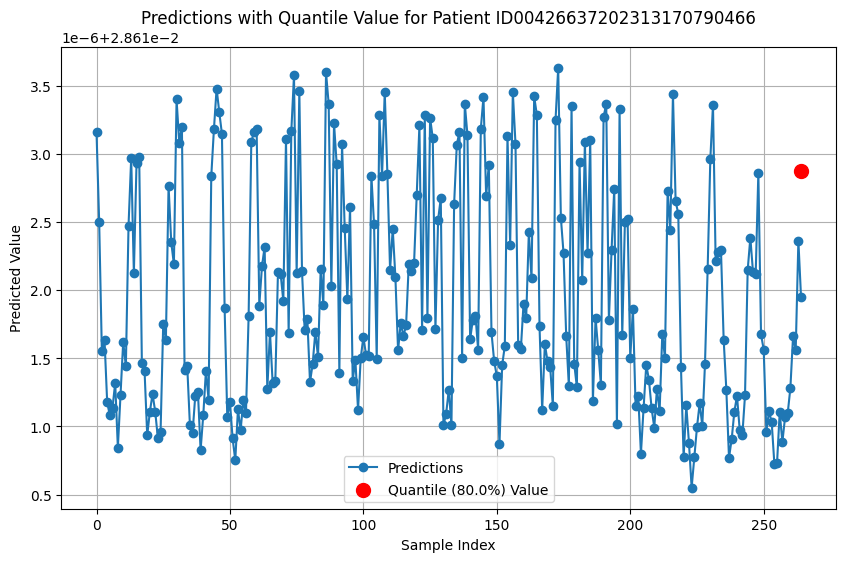

/var/folders/9q/pwqbdz21323f3j79799_2x7m0000gn/T/ipykernel_68267/1375259476.py:100: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3018.8613512]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[sub.Patient_Week == k, 'FVC'] = fvc
/var/folders/9q/pwqbdz21323f3j79799_2x7m0000gn/T/ipykernel_68267/1375259476.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[69.04820628]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[sub.Patient_Week == k, 'Confidence'] = (


In [13]:
subs = []
for model in models:
    metric = []
    for q in tqdm(range(1, 10)):
        m = []
        for p in vl_p:
            x = [] 
            tab = [] 

            if p in ['ID00011637202177653955184', 'ID00052637202186188008618']:
                continue

            ldir = os.listdir(f'osic-pulmonary-fibrosis-progression/train/{p}/')
            for i in ldir:
                if int(i[:-4]) / len(ldir) < 0.8 and int(i[:-4]) / len(ldir) > 0.15:
                    x.append(get_img(f'osic-pulmonary-fibrosis-progression/train/{p}/{i}')) 
                    tab.append(get_tab(train.loc[train.Patient == p, :])) 
            if len(x) < 1:
                continue
            tab = np.array(tab) 

            x = np.expand_dims(x, axis=-1) 
            _a = model.predict([x, tab]) 
            a = np.quantile(_a, q / 10)

            percent_true = train.Percent.values[train.Patient == p]
            fvc_true = train.FVC.values[train.Patient == p]
            weeks_true = train.Weeks.values[train.Patient == p]

            fvc = a * (weeks_true - weeks_true[0]) + fvc_true[0]
            percent = percent_true[0] - a * abs(weeks_true - weeks_true[0])
            m.append(score(fvc_true, fvc, percent))
            mean_metric=np.mean(m)
            print(f"Model: {model_classes[models.index(model)]}, Quantile: {q/10}, Mean Metric: {mean_metric}")
        print(np.mean(m))
        metric.append(np.mean(m))

    q = (np.argmin(metric) + 1)/ 10
    q=0.8
    sub = pd.read_csv('osic-pulmonary-fibrosis-progression/sample_submission.csv') 
    test = pd.read_csv('osic-pulmonary-fibrosis-progression/test.csv') 
    P_test = test.Patient.unique()

    print("Number of unique patient identifiers in the test set:", len(P_test))

    A_test, B_test, P_test,W, FVC= {}, {}, {},{},{} 
    STD, WEEK = {}, {} 
    quantile_values = []

    for p in test.Patient.unique():
        x = [] 
        tab = [] 
        ldir = os.listdir(f'osic-pulmonary-fibrosis-progression/test/{p}/')
        print(f"Processing Patient ID: {p}")

        for i in ldir:
            if int(i[:-4]) / len(ldir) < 0.8 and int(i[:-4]) / len(ldir) > 0.15:
                x.append(get_img(f'osic-pulmonary-fibrosis-progression/test/{p}/{i}')) 
                tab.append(get_tab(test.loc[test.Patient == p, :])) 
        if len(x) <= 1:
            continue
        tab = np.array(tab)

        x = np.expand_dims(x, axis=-1) 
        _a = model.predict([x, tab]) 
        a = np.quantile(_a, q)
        quantile_values.append(a)

        num_elements = _a.size
        print(num_elements)


        plt.figure(figsize=(10, 6))
        plt.plot(_a, marker='o', label='Predictions')
        # Highlighting the quantile value on the plot
        plt.scatter(len(_a)-1, a, color='red', s=100, label=f'Quantile ({q * 100}%) Value')
        plt.title(f'Predictions with Quantile Value for Patient {p}')
        plt.xlabel('Sample Index')
        plt.ylabel('Predicted Value')
        plt.grid(True)
        plt.legend()
        plt.show()




        A_test[p] = a
        B_test[p] = test.FVC.values[test.Patient == p] - a*test.Weeks.values[test.Patient == p]
        P_test[p] = test.Percent.values[test.Patient == p] 
        WEEK[p] = test.Weeks.values[test.Patient == p]

    for k in sub.Patient_Week.values:
        # p=patiehtnID
        # w=week to predict
        p, w = k.split('_')
        w = int(w) 
        fvc = A_test[p] * w + B_test[p] 

        # b
        sub.loc[sub.Patient_Week == k, 'FVC'] = fvc
        sub.loc[sub.Patient_Week == k, 'Confidence'] = (
            P_test[p] - A_test[p] * abs(WEEK[p] - w) 
            # P_test[p]: % predicted FVC
            # A_test[p]: predicted change in FVC per week for patient p
            # WEEK[p]: initial week
            )
         
    sub.to_csv('sub.csv', index=False)
    _sub = sub[["Patient_Week","FVC","Confidence"]].copy()
    subs.append(_sub)



Confidence rate

sub.loc[sub.Patient_Week == k, 'Confidence'] = (
    P_test[p] - A_test[p] * abs(WEEK[p] - w) 
) 

A_test[p]=predicted change in FVC per week
Week[p]=initial week
w=week for which prediction is made.

(Week[p]-w)=weeks elapsed

In [14]:
N = len(subs)
sub = subs[0].copy() # ref
sub["FVC"] = 0
sub["Confidence"] = 0
for i in range(N):
    sub["FVC"] += subs[i]["FVC"] * (1/N)
    print(sub["FVC"])
    sub["Confidence"] += subs[i]["Confidence"] * (1/N)



0      3018.861351
1      2737.342348
2      1928.861202
3      3292.176074
4      2924.656646
          ...     
725    3028.033800
726    2746.244554
727    1938.034851
728    3301.295704
729    2928.805512
Name: FVC, Length: 730, dtype: float64


Laplace Log Likelihood
Higher FVC: higher predicted lung capacity
Higher Confidence: greater uncertainty 

In [15]:
sub.head(10)


,Patient_Week,FVC,Confidence
0,ID00419637202311204720264_-12,3018.861351,69.048206
1,ID00421637202311550012437_-12,2737.342348,80.387639
2,ID00422637202311677017371_-12,1928.861202,75.533695
3,ID00423637202312137826377_-12,3292.176074,77.434977
4,ID00426637202313170790466_-12,2924.656646,71.481614
5,ID00419637202311204720264_-11,3018.924609,69.111465
6,ID00421637202311550012437_-11,2737.403742,80.449034
7,ID00422637202311677017371_-11,1928.924469,75.596962
8,ID00423637202312137826377_-11,3292.238968,77.497871
9,ID00426637202313170790466_-11,2924.685258,71.510226


In [7]:
sub[["Patient_Week","FVC","Confidence"]].to_csv("submission_img.csv", index=False)
img_sub = sub[["Patient_Week","FVC","Confidence"]].copy()


KeyError: "['Patient_Week', 'Confidence'] not in index"

Multiple Quantile Regression

In [2]:
ROOT = "osic-pulmonary-fibrosis-progression"
BATCH_SIZE=128

tr = pd.read_csv(f"{ROOT}/train.csv")
tr.drop_duplicates(keep=False, inplace=True, subset=['Patient','Weeks'])
chunk = pd.read_csv(f"{ROOT}/test.csv")

print("add infos")
sub = pd.read_csv(f"{ROOT}/sample_submission.csv")
sub['Patient'] = sub['Patient_Week'].apply(lambda x:x.split('_')[0])
sub['Weeks'] = sub['Patient_Week'].apply(lambda x: int(x.split('_')[-1]))
sub =  sub[['Patient','Weeks','Confidence','Patient_Week']]
sub = sub.merge(chunk.drop('Weeks', axis=1), on="Patient")

tr['WHERE'] = 'train'
chunk['WHERE'] = 'val'
sub['WHERE'] = 'test'


data = pd.concat([tr, chunk, sub], ignore_index=True)

add infos


qloss: quantile loss function for pinball loss (quantile loss)
mloss: combined loss function uses both qlose and score

In [3]:
print(tr.shape, chunk.shape, sub.shape, data.shape)
print(tr.Patient.nunique(), chunk.Patient.nunique(), sub.Patient.nunique(), 
      data.Patient.nunique())
data['min_week'] = data['Weeks']
data.loc[data.WHERE=='test','min_week'] = np.nan
data['min_week'] = data.groupby('Patient')['min_week'].transform('min')
base = data.loc[data.Weeks == data.min_week]
base = base[['Patient','FVC']].copy()
base.columns = ['Patient','min_FVC']
base['nb'] = 1
base['nb'] = base.groupby('Patient')['nb'].transform('cumsum')
base = base[base.nb==1]
base.drop('nb', axis=1, inplace=True)
data = data.merge(base, on='Patient', how='left')
data['base_week'] = data['Weeks'] - data['min_week']
del base
COLS = ['Sex','SmokingStatus'] #,'Age'
FE = []
for col in COLS:
    for mod in data[col].unique():
        FE.append(mod)
        data[mod] = (data[col] == mod).astype(int)

data['age'] = (data['Age'] - data['Age'].min() ) / ( data['Age'].max() - data['Age'].min() )
data['BASE'] = (data['min_FVC'] - data['min_FVC'].min() ) / ( data['min_FVC'].max() - data['min_FVC'].min() )
data['week'] = (data['base_week'] - data['base_week'].min() ) / ( data['base_week'].max() - data['base_week'].min() )
data['percent'] = (data['Percent'] - data['Percent'].min() ) / ( data['Percent'].max() - data['Percent'].min() )
FE += ['age','percent','week','BASE']

tr = data.loc[data.WHERE=='train']
chunk = data.loc[data.WHERE=='val']
sub = data.loc[data.WHERE=='test']
del data
C1, C2 = tf.constant(70, dtype='float32'), tf.constant(1000, dtype="float32")

def score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)  # Cast y_true to float32
    y_pred = tf.cast(y_pred, tf.float32)  # Cast y_pred to float32
    sigma = y_pred[:, 2] - y_pred[:, 0]
    fvc_pred = y_pred[:, 1]
    
    sigma_clip = tf.maximum(sigma, C1)
    delta = tf.abs(y_true[:, 0] - fvc_pred)  # Both y_true and fvc_pred are now float32
    delta = tf.minimum(delta, C2)
    sq2 = tf.sqrt(tf.constant(2, dtype=tf.float32))
    metric = (delta / sigma_clip) * sq2 + tf.math.log(sigma_clip * sq2)
    return tf.reduce_mean(metric)

def qloss(y_true, y_pred):
    # Pinball loss for multiple quantiles
    qs = [0.2, 0.50, 0.8]
    q = tf.constant(np.array([qs]), dtype=tf.float32)
    y_true = tf.cast(y_true, tf.float32)  # Cast y_true to float32
    y_pred = tf.cast(y_pred, tf.float32)  # Ensure y_pred is also float32
    e = y_true - y_pred
    v = tf.maximum(q*e, (q-1)*e)
    return K.mean(v)

def mloss(_lambda):
    def loss(y_true, y_pred):
        return _lambda * qloss(y_true, y_pred) + (1 - _lambda)*score(y_true, y_pred)
    return loss

def make_model(nh):
    z = L.Input((nh,), name="Patient")
    x = L.Dense(100, activation="relu", name="d1")(z)
    x = L.Dense(100, activation="relu", name="d2")(x)
    #x = L.Dense(100, activation="relu", name="d3")(x)
    p1 = L.Dense(3, activation="linear", name="p1")(x)
    p2 = L.Dense(3, activation="relu", name="p2")(x)
    preds = L.Lambda(lambda x: x[0] + tf.cumsum(x[1], axis=1), 
                     name="preds")([p1, p2])
    
    model = M.Model(z, preds, name="CNN")
    #model.compile(loss=qloss, optimizer="adam", metrics=[score])
    model.compile(loss=mloss(0.8), optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.1, beta_1=0.9, beta_2=0.999, epsilon=None, amsgrad=False), metrics=[score])
    return model

y = tr['FVC'].values
z = tr[FE].values
ze = sub[FE].values
nh = z.shape[1]
pe = np.zeros((ze.shape[0], 3))
pred = np.zeros((z.shape[0], 3))

(1535, 8) (5, 8) (730, 10) (2270, 10)
176 5 5 176


In [4]:
net = make_model(nh)
print(net.summary())
print(net.count_params())


Model: "CNN"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 Patient (InputLayer)        [(None, 9)]                  0         []                            
                                                                                                  
 d1 (Dense)                  (None, 100)                  1000      ['Patient[0][0]']             
                                                                                                  
 d2 (Dense)                  (None, 100)                  10100     ['d1[0][0]']                  
                                                                                                  
 p1 (Dense)                  (None, 3)                    303       ['d2[0][0]']                  
                                                                                                

In [5]:
NFOLD = 5 # originally 5
kf = KFold(n_splits=NFOLD)

cnt = 0
EPOCHS = 800
for tr_idx, val_idx in kf.split(z):
    cnt += 1
    print(f"FOLD {cnt}")
    print(f"Training on {len(tr_idx)} samples")  # Print the number of training samples
    print(f"Validating on {len(val_idx)} samples")  # Print the number of validation samples


    net = make_model(nh)
    net.fit(z[tr_idx], y[tr_idx], batch_size=BATCH_SIZE, epochs=EPOCHS, 
            validation_data=(z[val_idx], y[val_idx]), verbose=0) #
    print("train", net.evaluate(z[tr_idx], y[tr_idx], verbose=0, batch_size=BATCH_SIZE))
    print("val", net.evaluate(z[val_idx], y[val_idx], verbose=0, batch_size=BATCH_SIZE))
    print("predict val...\n\n")
    pred[val_idx] = net.predict(z[val_idx], batch_size=BATCH_SIZE, verbose=0)
    print(pred)
    pe += net.predict(ze, batch_size=BATCH_SIZE, verbose=0) / NFOLD


FOLD 1
Training on 1228 samples
Validating on 307 samples
train [23.912202835083008, 6.004552841186523]
val [59.17710494995117, 7.054168701171875]
predict val...
predict test...
FOLD 2
Training on 1228 samples
Validating on 307 samples
train [25.17515754699707, 5.997036933898926]
val [58.70808029174805, 7.2027587890625]
predict val...
predict test...
FOLD 3
Training on 1228 samples
Validating on 307 samples
train [27.195016860961914, 6.135573387145996]
val [67.38809967041016, 7.042031764984131]
predict val...
predict test...
FOLD 4
Training on 1228 samples
Validating on 307 samples
train [25.90363311767578, 6.006731986999512]
val [51.439476013183594, 6.8003058433532715]
predict val...
predict test...
FOLD 5
Training on 1228 samples
Validating on 307 samples
train [28.92953109741211, 6.116246700286865]
val [64.9048080444336, 7.258317470550537]
predict val...
predict test...


169.62271279201445 162.24238368727097


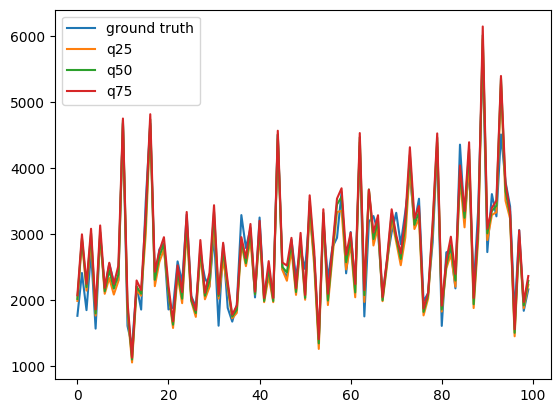

In [6]:
sigma_opt = mean_absolute_error(y, pred[:, 1])
unc = pred[:,2] - pred[:, 0]
sigma_mean = np.mean(unc)
print(sigma_opt, sigma_mean)
idxs = np.random.randint(0, y.shape[0], 100)
plt.plot(y[idxs], label="ground truth")
plt.plot(pred[idxs, 0], label="q25")
plt.plot(pred[idxs, 1], label="q50")
plt.plot(pred[idxs, 2], label="q75")
plt.legend(loc="best")
plt.show()


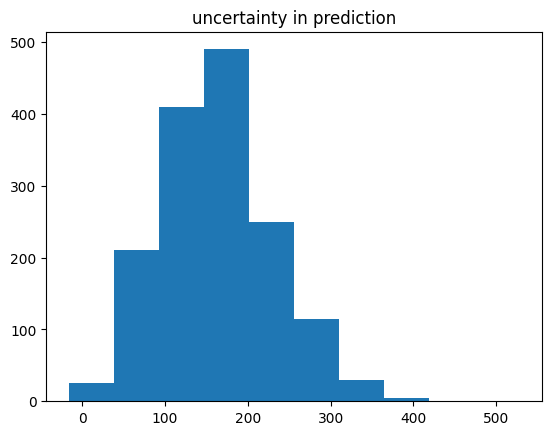

In [7]:
plt.hist(unc)
plt.title("uncertainty in prediction")
plt.show()


In [8]:
sub.head()
# PREDICTION
sub['FVC1'] = 1.*pe[:, 1]
sub['Confidence1'] = pe[:, 2] - pe[:, 0]
subm = sub[['Patient_Week','FVC','Confidence','FVC1','Confidence1']].copy()
subm.loc[~subm.FVC1.isnull()].head(10)

,Patient_Week,FVC,Confidence,FVC1,Confidence1
1540,ID00224637202259281193413_-12,2812,100.0,2848.441284,160.410339
1541,ID00285637202278913507108_-12,1304,100.0,1492.519836,105.867737
1542,ID00051637202185848464638_-12,1532,100.0,1622.591187,82.533173
1543,ID00168637202237852027833_-12,2711,100.0,2852.233032,209.795898
1544,ID00127637202219096738943_-12,1551,100.0,1747.413116,25.847076
1545,ID00224637202259281193413_-11,2812,100.0,2846.448120,161.251892
1546,ID00285637202278913507108_-11,1304,100.0,1490.553558,106.624695
1547,ID00051637202185848464638_-11,1532,100.0,1619.887970,82.847931
1548,ID00168637202237852027833_-11,2711,100.0,2849.113098,210.477173
1549,ID00127637202219096738943_-11,1551,100.0,1743.919861,25.521759


In [16]:
subm['FVC'] = subm['FVC'].astype(float)
subm['Confidence'] = subm['Confidence'].astype(float)
subm['FVC1'] = subm['FVC1'].astype(float)
subm['Confidence1'] = subm['Confidence1'].astype(float)


subm.loc[~subm.FVC1.isnull(),'FVC'] = subm.loc[~subm.FVC1.isnull(),'FVC1']
if sigma_mean<70:
    subm['Confidence'] = sigma_opt
else:
    subm.loc[~subm.FVC1.isnull(),'Confidence'] = subm.loc[~subm.FVC1.isnull(),'Confidence1']



otest = pd.read_csv('osic-pulmonary-fibrosis-progression/test.csv')
otest['Patient'] = otest['Patient'].astype(str)
otest['Weeks'] = otest['Weeks'].astype(int)

# Update the 'FVC' and 'Confidence' in 'subm' based on 'otest'
for i in range(len(otest)):
    patient_week = f"{otest.Patient[i]}_{otest.Weeks[i]}"
    subm.loc[subm['Patient_Week'] == patient_week, 'FVC'] = otest.FVC[i]
    subm.loc[subm['Patient_Week'] == patient_week, 'Confidence'] = 0.1

# Verify the updates
print(subm.head())
#ßprint(subm.describe().T)
subm.head()
subm.describe().T

subm[["Patient_Week","FVC","Confidence"]].to_csv("submission_regression.csv", index=False)
reg_sub = subm[["Patient_Week","FVC","Confidence"]].copy()

                       Patient_Week          FVC  Confidence         FVC1  \
1540  ID00224637202259281193413_-12  2848.441284  160.410339  2848.441284   
1541  ID00285637202278913507108_-12  1492.519836  105.867737  1492.519836   
1542  ID00051637202185848464638_-12  1622.591187   82.533173  1622.591187   
1543  ID00168637202237852027833_-12  2852.233032  209.795898  2852.233032   
1544  ID00127637202219096738943_-12  1747.413116   25.847076  1747.413116   

      Confidence1  
1540   160.410339  
1541   105.867737  
1542    82.533173  
1543   209.795898  
1544    25.847076  


weighted blending.

In [ ]:
img_sub = img_sub.sort_values(by=['Patient_Week'], ascending=True).reset_index(drop=True)
reg_sub = reg_sub.sort_values(by=['Patient_Week'], ascending=True).reset_index(drop=True)

# Normalize weights
total_weight = sum(efficientnet_weight) + qr_weight
normalized_efficientnet_weight = [w / total_weight for w in efficientnet_weight]
normalized_qr_weight = qr_weight / total_weight

# Apply weights to predictions
# Compute the weighted average for FVC and Confidence
weighted_fvc = np.average(
    [img_sub['FVC'], reg_sub['FVC']], 
    axis=0, 
    weights=[normalized_efficientnet_weight, normalized_qr_weight]
)
weighted_confidence = np.average(
    [img_sub['Confidence'], reg_sub['Confidence']], 
    axis=0, 
    weights=[normalized_efficientnet_weight, normalized_qr_weight]
)

# Creating a blended submission dataframe
blended_submission = pd.DataFrame({
    'Patient_Week': img_sub['Patient_Week'],
    'FVC': weighted_fvc,
    'Confidence': weighted_confidence
})
blended_submission.to_csv('blended_submission.csv', index=False)



NameError: name 'efficientnet_weight' is not defined